In [2]:
import random
random.seed(42)
import time
import numpy as np
import h5py
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style('white')
sns.set_style('ticks')
#import bcolz
import pandas
import allel; print('scikit-allel', allel.__version__)
%reload_ext memory_profiler
from itertools import compress
from collections import *
from functools import reduce
import pandas as pd

scikit-allel 1.3.5


In [472]:
def plot_pca_coords(coords, model, pc1, pc2, ax, sample_population):
    sns.despine(ax=ax, offset=5)
    x = coords[:, pc1]
    y = coords[:, pc2]
    for pop in populations:
        flt = (sample_population == pop)
        ax.plot(x[flt], y[flt], marker='o', linestyle=' ', color=pop_colours[pop], 
                label=pop, markersize=6, mec='k', mew=.5)
    ax.set_xlabel('PC%s (%.1f%%)' % (pc1+1, model.explained_variance_ratio_[pc1]*100))
    ax.set_ylabel('PC%s (%.1f%%)' % (pc2+1, model.explained_variance_ratio_[pc2]*100))
    

def fig_pca(coords, model, title, sample_population=None):
    if sample_population is None:
        sample_population = df_samples.population.values
    # plot coords for PCs 1 vs 2, 3 vs 4
    fig = plt.figure(figsize=(10, 5), dpi = 500)
    ax = fig.add_subplot(1, 2, 1)
    plot_pca_coords(coords, model, 0, 1, ax, sample_population)
    ax = fig.add_subplot(1, 2, 2)
    plot_pca_coords(coords, model, 2, 3, ax, sample_population)
    ax.legend(bbox_to_anchor=(1, 1), loc='upper left')
    fig.suptitle(title, y=1.02)
    fig.tight_layout()

In [473]:
def filterPos(start, end, Pos):
    '''
    return subset gt[start : end]
    '''
    filter_list = []
    for x in Pos:
        filter_list.append(True if end >= x >= start else False)
    return filter_list 

In [474]:
#callset = allel.read_vcf("/Users/rainlam/QUL/QUL.LG1.vcf.gz")
callset = allel.read_vcf("/Users/rainlam/Quare.LG12.filter.vcf.gz")
df_samples = pandas.read_csv('/Users/rainlam/Quare.pop', delimiter='\t')
df_samples.head()

populations = df_samples.population.unique()[:19]
pop_colours = {
    'H_female': 'red',
    'H_male': 'blue',
    'L_male':'skyblue',
    'L_female':'pink'
}


/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/allel/io/vcf_read.py:1732: UserWarning: invalid INFO header: '##INFO=<ID=VDB,Number=1,Type=Float,Description="Variant Distance Bias for filtering splice-site artefacts in RNA-seq data (bigger is better)",Version="3">\n'
  warnings.warn('invalid INFO header: %r' % header)


In [269]:
df_samples.population.values

array(['H_female', 'H_female', 'H_female', 'H_female', 'H_female',
       'H_female', 'H_female', 'H_female', 'H_female', 'H_female',
       'H_male', 'H_male', 'H_male', 'H_male', 'H_male', 'H_male',
       'H_male', 'H_male', 'H_male', 'L_female', 'L_female', 'L_female',
       'L_female', 'L_female', 'L_female', 'L_female', 'L_female',
       'L_female', 'L_female', 'L_male', 'L_male', 'L_male', 'L_male',
       'L_male', 'L_male', 'L_male', 'L_male', 'L_male', 'L_male'],
      dtype=object)

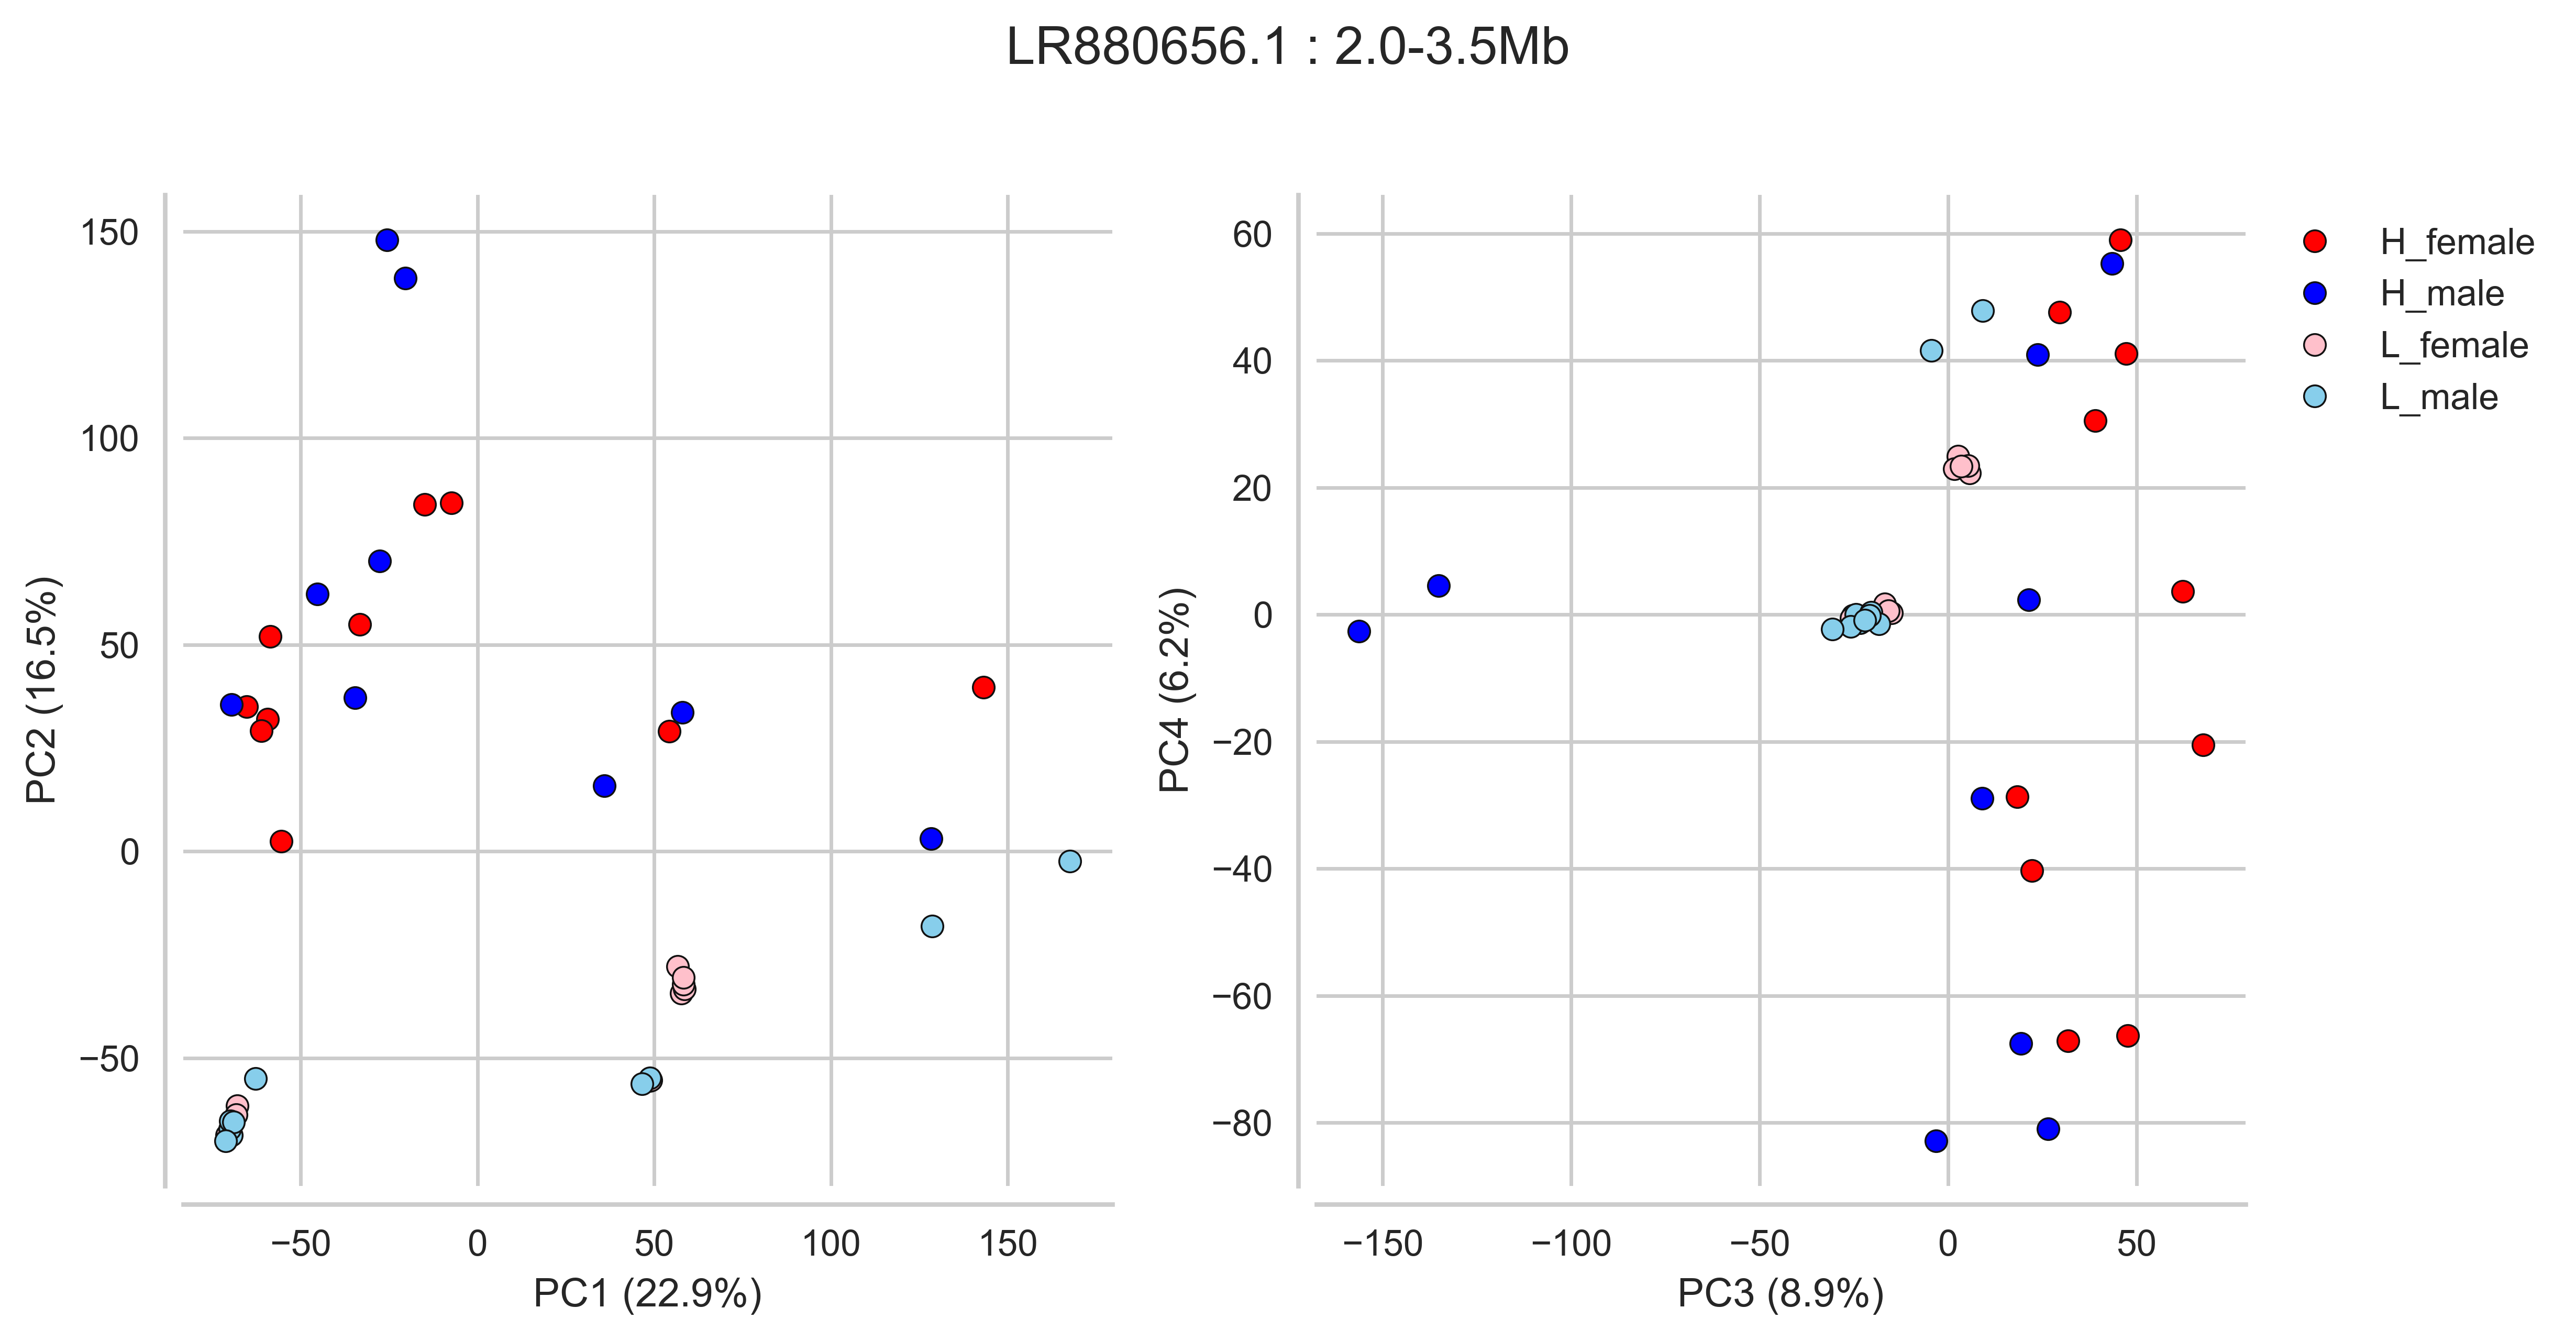

In [478]:
# read vcf file and make genotype matrix
#callset = allel.read_vcf("/Users/rainlam/Project/3.SV/pca_result/test.recode.vcf")
#callset = allel.read_vcf("/Users/rainlam/Project/3.SV/localPCA/local_pca/templated/data/Aripo.LG4.vcf.gz")
#callset = allel.read_vcf("/Users/rainlam/QUL/QUL.LG1.vcf.gz")
# population 
#df_samples = pandas.read_csv('/Users/rainlam/QUL/QUL.pop', delimiter='\t')
#df_samples.head()

populations = df_samples.population.unique()
pop_colours = {
    'H_female': 'red',
    'H_male': 'blue',
    'L_male':'skyblue',
    'L_female':'pink'
}

#chromosome
chrom = callset['variants/CHROM'][0]

start = 2000000
end = 3500000
genotype = allel.GenotypeChunkedArray(callset['calldata/GT'])
# position array 
tmp_pos = np.array(filterPos(start, end, callset["variants/POS"]))
# subset of gt in [start_pos, end_pos]
subset_gt = genotype.compress(tmp_pos, axis=0)
# allele count
ac = subset_gt.count_alleles()[:] 
# filter singleton SNPs and missing SNPs, only keep biallelic 
flt = (ac.max_allele() == 1) & (ac[:, :2].min(axis=1) > 1)
gf = subset_gt.compress(flt, axis=0) # actual SNP filterings
gn = gf.to_n_alt()

# plotting 
coords1, model1 = allel.pca(gn, n_components=10, scaler='patterson')
fig_pca(coords1, model1, "{} : {}-{}Mb".format(chrom, start/1e6, end/1e6))

In [479]:
model1.explained_variance_ratio_[1]

0.16517906

In [480]:
from sklearn.cluster import KMeans

array([[ -7.3003488],
       [-59.352562 ],
       [-33.281578 ],
       [-61.227135 ],
       [ 54.3337   ],
       [-58.674416 ],
       [-65.31107  ],
       [143.1071   ],
       [-14.95233  ],
       [-55.470768 ],
       [-34.67448  ],
       [-25.665691 ],
       [-69.563614 ],
       [128.3656   ],
       [ 35.908287 ],
       [-45.26647  ],
       [ 57.98707  ],
       [-27.621733 ],
       [-20.346771 ],
       [ 48.674435 ],
       [-70.92814  ],
       [ 57.68319  ],
       [ 58.510006 ],
       [ 56.656746 ],
       [ 58.33216  ],
       [-68.036606 ],
       [ 49.06061  ],
       [ 58.295086 ],
       [-68.21476  ],
       [-69.546364 ],
       [-62.729    ],
       [128.71053  ],
       [-70.00161  ],
       [-69.90175  ],
       [167.64717  ],
       [ 48.74578  ],
       [ 46.625793 ],
       [-69.07786  ],
       [-71.29465  ]], dtype=float32)

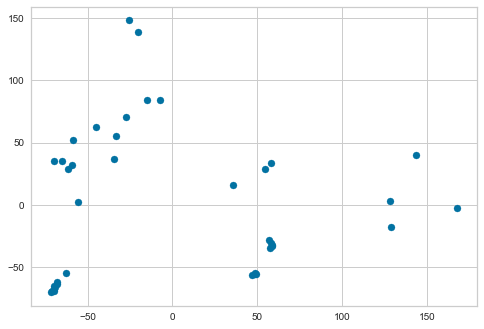

In [481]:
plt.scatter(coords1[:,:1],coords1[:,1:2])
coords1[:,:1]

In [482]:
df2 = pd.DataFrame(coords1[:,:2], columns = ["PC1", "PC2"])
df2

,PC1,PC2
0,-7.300349,84.246246
1,-59.352562,31.944180
2,-33.281578,54.890011
3,-61.227135,29.109032
4,54.333698,29.061165
5,-58.674416,51.943836
6,-65.311073,34.954113
7,143.107101,39.712814
8,-14.952330,83.955856
9,-55.470768,2.448451


In [498]:
df = pd.DataFrame(coords1[:,:2], columns = ["PC1", 'PC2'])
df

,PC1,PC2
0,-7.300349,84.246246
1,-59.352562,31.944180
2,-33.281578,54.890011
3,-61.227135,29.109032
4,54.333698,29.061165
5,-58.674416,51.943836
6,-65.311073,34.954113
7,143.107101,39.712814
8,-14.952330,83.955856
9,-55.470768,2.448451


In [503]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(df)

KMeans(n_clusters=3)

In [504]:
df['cluster'] = kmeans.predict(df)

In [506]:
df

,PC1,PC2,cluster
0,-7.300349,84.246246,1
1,-59.352562,31.944180,1
2,-33.281578,54.890011,1
3,-61.227135,29.109032,1
4,54.333698,29.061165,0
5,-58.674416,51.943836,1
6,-65.311073,34.954113,1
7,143.107101,39.712814,0
8,-14.952330,83.955856,1
9,-55.470768,2.448451,1


In [507]:
import mglearn
import matplotlib.pyplot as plt

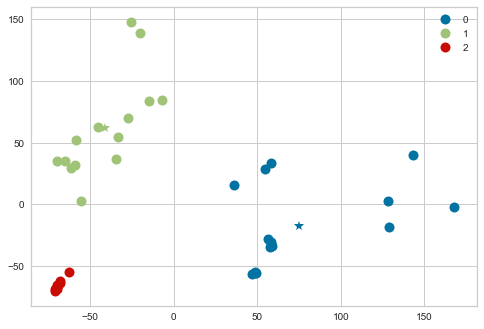

In [508]:
mglearn.discrete_scatter(df['PC1'], df['PC2'], kmeans.labels_, markers='o')
plt.legend()
mglearn.discrete_scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],[0,1,2], markers='*')

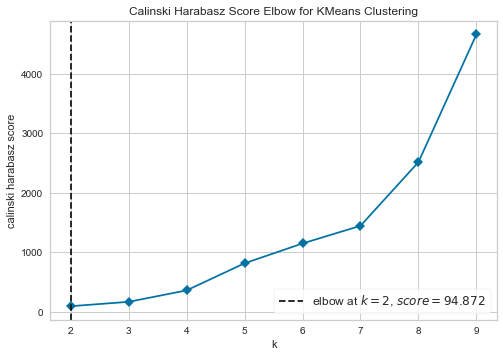

<AxesSubplot:title={'center':'Calinski Harabasz Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='calinski harabasz score'>

In [452]:
# elbow method
from yellowbrick.cluster import KElbowVisualizer
# Instantiate the clustering model and visualizer
model = KMeans()
visualizer = KElbowVisualizer(
    model, k=(2,10), metric='calinski_harabasz', timings=False
)

visualizer.fit(df)        # Fit the data to the visualizer
visualizer.show() 

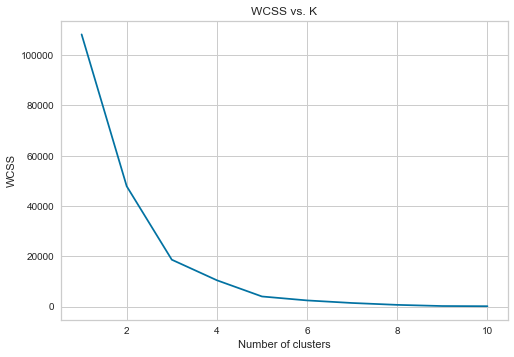

In [404]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# load the data into a pandas DataFrame


# determine the optimal number of clusters using the elbow method
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(df)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.title('WCSS vs. K')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()


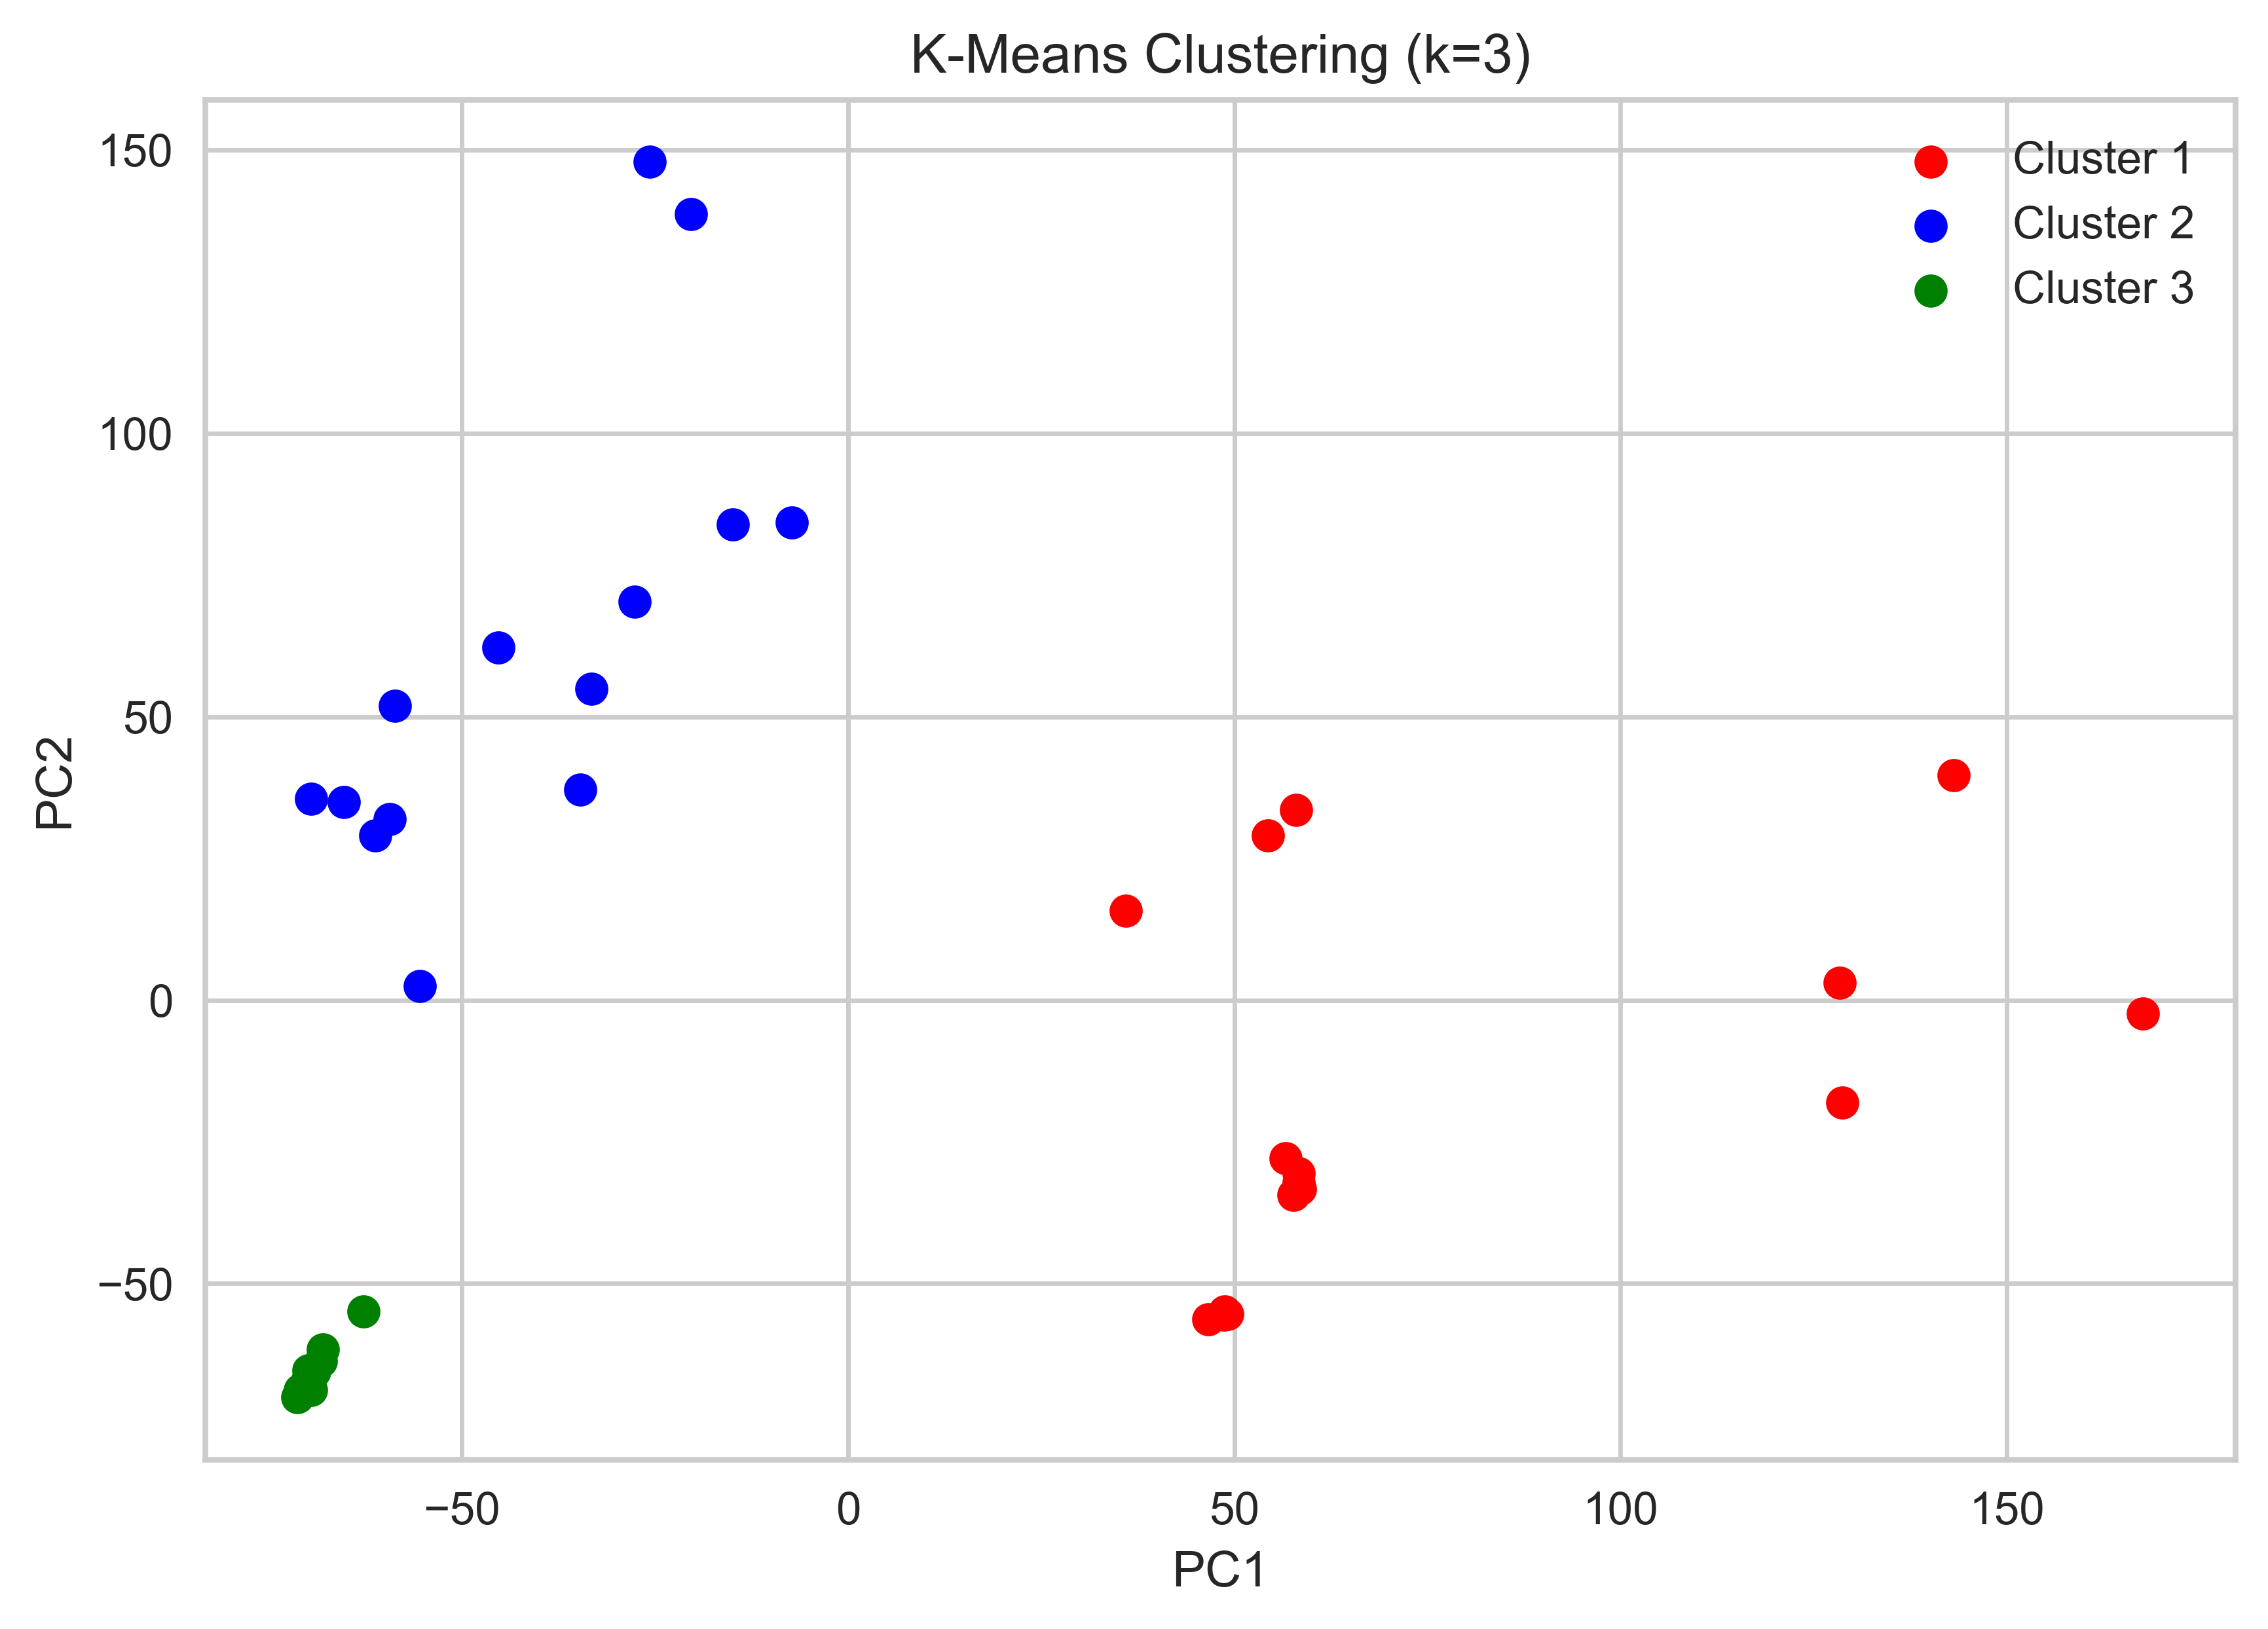

In [512]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
plt.figure(dpi = 500)

# Read data into a pandas dataframe


# Perform k-means clustering with k=3
kmeans = KMeans(n_clusters=3, random_state=0).fit(df)

# Add the cluster labels as a new column in the dataframe
df2['cluster'] = kmeans.labels_

# Plot the clusters
plt.scatter(df.loc[df['Cluster'] == 0, 'PC1'], df.loc[df['Cluster'] == 0, 'PC2'], color='red', label='Cluster 1')
plt.scatter(df.loc[df['Cluster'] == 1, 'PC1'], df.loc[df['Cluster'] == 1, 'PC2'], color='blue', label='Cluster 2')
plt.scatter(df.loc[df['Cluster'] == 2, 'PC1'], df.loc[df['Cluster'] == 2, 'PC2'], color='green', label='Cluster 3')

plt.title('K-Means Clustering (k=3)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()


In [459]:
df

,PC1
0,-4.308251
1,-47.397194
2,-33.436790
3,-44.196671
4,64.826904
5,-44.563305
6,-49.928879
7,138.960876
8,-12.481089
9,-49.884987


[1 1 1 1 0 1 1 0 1 1 1 1 1 0 0 1 0 1 1 0 2 0 0 0 0 2 0 0 2 2 2 0 2 2 0 0 0
 2 2]


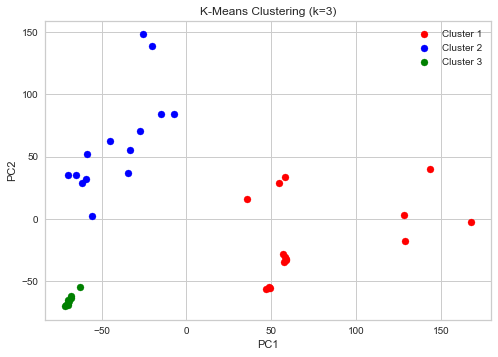

In [511]:
import pandas as pd
from sklearn.cluster import KMeans

# Define the weights for each dimension
weights = [280000000, 0]

# Load the data into a Pandas DataFrame


# Define the weighted distance function
def weighted_dist(x1, x2, weights):
    return np.sqrt(np.sum(weights * (x1 - x2)**2))

# Define the weighted k-means clustering algorithm
class WeightedKMeans(KMeans):
    def __init__(self, n_clusters, weights, **kwargs):
        self.weights = np.array(weights)
        super().__init__(n_clusters, **kwargs)

    def _euclidean_dist(self, X):
        return super()._euclidean_dist(X) * np.sqrt(X.shape[1]) / np.linalg.norm(self.weights)

    def _transform(self, X):
        return X * np.sqrt(X.shape[1]) / np.linalg.norm(self.weights)

# Create an instance of the weighted k-means algorithm
kmeans = WeightedKMeans(n_clusters=3, weights=weights)

# Fit the algorithm to the data
kmeans.fit(df)

# Print the cluster assignments for each data point
print(kmeans.labels_)
df["Cluster"] = kmeans.labels_
plt.scatter(df.loc[df['Cluster'] == 0, 'PC1'], df.loc[df['Cluster'] == 0, 'PC2'], color='red', label='Cluster 1')
plt.scatter(df.loc[df['Cluster'] == 1, 'PC1'], df.loc[df['Cluster'] == 1, 'PC2'], color='blue', label='Cluster 2')
plt.scatter(df.loc[df['Cluster'] == 2, 'PC1'], df.loc[df['Cluster'] == 2, 'PC2'], color='green', label='Cluster 3')

plt.title('K-Means Clustering (k=3)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()


No handles with labels found to put in legend.


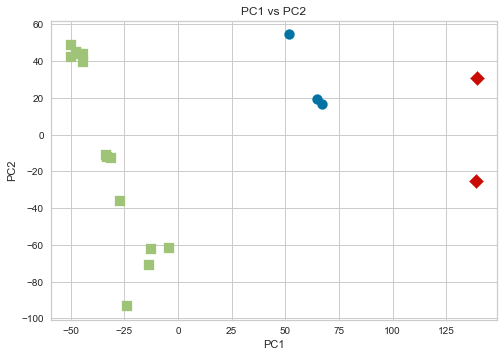

In [466]:
import matplotlib.pyplot as plt
import pandas as pd

# Load the data into a Pandas DataFrame

# Create a scatter plot with different colors for each cluster
plt.scatter(df2['PC1'], df2['PC2'], c=df2['cluster'], cmap='Set1')

# Add markers for each value in the 'Cluster' column
# You can choose different markers for each value by passing a list
# of marker types to the 'marker' parameter
markers = ['o', 's', 'D']
for i, marker in enumerate(markers):
    subset = df2[df2['Cluster'] == i]
    plt.scatter(subset['PC1'], subset['PC2'], marker=marker, s=100)

# Add axis labels and a title
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PC1 vs PC2')
plt.legend()
# Show the plot
plt.show()


In [469]:
df = df2

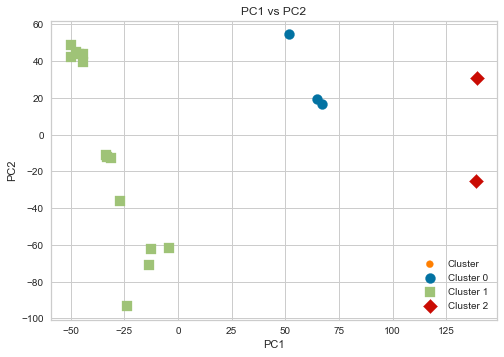

In [470]:
import matplotlib.pyplot as plt
import pandas as pd


# Create a scatter plot with different colors for each cluster
plt.scatter(df['PC1'], df['PC2'], c=df['cluster'], cmap='Set1', label='Cluster')

# Add markers for each value in the 'Cluster' column
# You can choose different markers for each value by passing a list
# of marker types to the 'marker' parameter
markers = ['o', 's', 'D']
for i, marker in enumerate(markers):
    subset = df[df['Cluster'] == i]
    plt.scatter(subset['PC1'], subset['PC2'], marker=marker, s=100, label=f'Cluster {i}')

# Add axis labels and a title
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PC1 vs PC2')

# Add legends
plt.legend()

# Show the plot
plt.show()


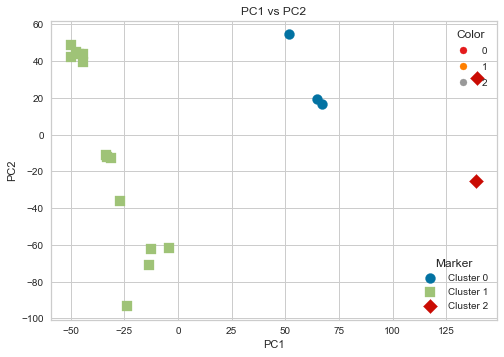

In [471]:
import matplotlib.pyplot as plt
import pandas as pd

# Load the data into a Pandas DataFrame

# Create a scatter plot with different colors for each cluster
scatter1 = plt.scatter(df['PC1'], df['PC2'], c=df['cluster'], cmap='Set1', label='Cluster')

# Add markers for each value in the 'Cluster' column
# You can choose different markers for each value by passing a list
# of marker types to the 'marker' parameter
markers = ['o', 's', 'D']
handles = []
for i, marker in enumerate(markers):
    subset = df[df['Cluster'] == i]
    scatter2 = plt.scatter(subset['PC1'], subset['PC2'], marker=marker, s=100, label=f'Cluster {i}')
    handles.append(scatter2)

# Add axis labels and a title
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PC1 vs PC2')

# Create the first legend for the color
legend1 = plt.legend(*scatter1.legend_elements(), title='Color', loc='upper right')
plt.gca().add_artist(legend1)

# Create the second legend for the markers
legend2 = plt.legend(handles, [f'Cluster {i}' for i in range(len(markers))], title='Marker', loc='lower right')

# Show the plot
plt.show()
